In [1]:
from langgraph.graph import StateGraph, START , END 
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
from typing import TypedDict,Annotated
from dotenv import load_dotenv
from pydantic import BaseModel , Field
import operator

In [2]:
load_dotenv()
llm = HuggingFaceEndpoint(
    # repo_id="meta-llama/Llama-3.1-8B-Instruct",  # Choose any model supporting Inference API
    repo_id = "Qwen/Qwen2.5-Coder-7B-Instruct",
    task="text-generation",
    max_new_tokens=512,
    do_sample=False,
    repetition_penalty=1.03,
    temperature=0.7,
)

# 2. Wrap with ChatHuggingFace
model = ChatHuggingFace(llm=llm, verbose=True)



d:\langgraph\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
class EvalState(TypedDict):
    essay : str
    clarity_feedback : str
    depth_feedback : str 
    language_feedback : str
    overall_feedback : str

    individual_scores : Annotated[list[int],operator.add]
    avg_score : float



In [4]:
from langchain_core.output_parsers import PydanticOutputParser
from langchain_core.prompts import PromptTemplate
from pydantic import BaseModel, Field

# 1. Define Schema
class EvaluationSchema(BaseModel):
    feedback: str = Field(description="detailed feedback of the essay")
    score: int = Field(description="score out of 10", ge=0, le=10)

# 2. Initialize Parser
parser = PydanticOutputParser(pydantic_object=EvaluationSchema)


In [5]:


def eval_language(state:EvalState)->EvalState:
    essay = state["essay"]
    prompt = PromptTemplate(
        template=(
            "Evaluate the language quality of the following essay and provide "
            "feedback and a score out of 10.\n\n{essay}\n\n{format_instructions}"
        ),
        input_variables=["essay"],
        partial_variables={"format_instructions": parser.get_format_instructions()},
    )
    chain = prompt | model | parser   # model = your plain ChatHuggingFace, no with_structured_output
    output = chain.invoke({"essay": essay})
    language_feedback = output.feedback
    score = output.score
    
    return {'language_feedback':language_feedback,"individual_scores":[score]}



In [6]:
def eval_clarity(state:EvalState)->EvalState:
    essay = state["essay"]
    prompt = PromptTemplate(
        template=(
            "Evaluate the clarity of thought of the following essay and provide "
            "feedback and a score out of 10.\n\n{essay}\n\n{format_instructions}"
        ),
        input_variables=["essay"],
        partial_variables={"format_instructions": parser.get_format_instructions()},
    )
    chain = prompt | model | parser   # model = your plain ChatHuggingFace, no with_structured_output
    output = chain.invoke({"essay": essay})
    clarity_feedback = output.feedback
    score = output.score
    
    return {'clarity_feedback':clarity_feedback,"individual_scores":[score]}

In [7]:
def eval_depth(state:EvalState)->EvalState:
    essay = state["essay"]
    prompt = PromptTemplate(
        template=(
            "Evaluate the depth of analysis of the following essay and provide "
            "feedback and a score out of 10.\n\n{essay}\n\n{format_instructions}"
        ),
        input_variables=["essay"],
        partial_variables={"format_instructions": parser.get_format_instructions()},
    )
    chain = prompt | model | parser  
    output = chain.invoke({"essay": essay})
    depth_feedback = output.feedback
    score = output.score
    
    return {'depth_feedback':depth_feedback,"individual_scores":[score]}

In [8]:
def final_evaluation(state:EvalState)->EvalState:
    prompt =f"Based on the following feedbacks create a summarized feedback \nlanguage feedback - {state['language_feedback']}\nclarity of thought feedback - {state['clarity_feedback']}\nDepth of analysis feedback - {state['depth_feedback']}"
    overall_feedback = model.invoke(prompt).content

    #avg calculation 
    avg_score = sum(state["individual_scores"])/(len(state["individual_scores"]))

    return {"overall_feedback": overall_feedback,"avg_score":avg_score}

In [9]:
# define graph 

graph = StateGraph(EvalState)

# define nodes 
graph.add_node("eval_clarity",eval_clarity)
graph.add_node("eval_depth",eval_depth)
graph.add_node("eval_language",eval_language)
graph.add_node("final_evaluation",final_evaluation)

# define edge connections 
graph.add_edge(START,"eval_clarity")
graph.add_edge(START,"eval_depth")
graph.add_edge(START,"eval_language")

graph.add_edge("eval_clarity","final_evaluation")
graph.add_edge("eval_depth","final_evaluation")
graph.add_edge("eval_language","final_evaluation")

graph.add_edge("final_evaluation",END)


#compile graph 
workflow = graph.compile()

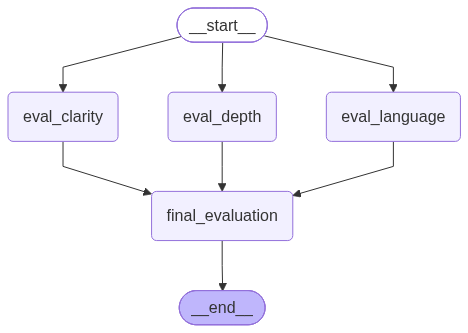

In [10]:
workflow

In [11]:
#initial state 
initial_state = {"essay":"""The Silent Co-Worker: Navigating the Ethics of AI in the 2026 Workforce
Introduction
By 2026, Artificial Intelligence (AI) has transitioned from a novel buzzword to a silent, ubiquitous co-worker present in nearly every industry. From algorithms diagnosing diseases in healthcare to autonomous systems managing supply chains, AI’s integration has promised unprecedented efficiency and economic growth. However, this rapid deployment has ignited a fierce ethical debate. While AI offers the potential to liberate humans from mundane tasks, its unchecked integration threatens to exacerbate economic inequality, erode privacy, and diminish human agency. To harness the benefits of this technology without sacrificing societal well-being, we must establish robust ethical frameworks that prioritize human welfare over pure automation.

The Displacement Dilemma
The most immediate ethical concern surrounding AI is the displacement of human labor. Unlike previous industrial revolutions that primarily affected manual labor, the AI revolution of the 2020s has encroached upon cognitive and creative domains. Jobs in coding, content creation, legal analysis, and even diagnostic medicine are now partially or fully automated. Proponents argue that AI creates new roles focused on oversight and strategy. However, the transition period leaves millions vulnerable. The ethical failure lies not in the technology itself, but in the lack of systemic support for displaced workers. Without aggressive reskilling initiatives and perhaps a reimagined social safety net, such as Universal Basic Income (UBI), AI risks creating a permanent underclass of unemployable individuals, widening the wealth gap to dangerous levels.

Algorithmic Bias and Discrimination
Beyond economics, AI systems perpetuate and often amplify existing societal biases. AI models are trained on historical data, which inevitably contains human prejudices regarding race, gender, and socioeconomic status. In 2026, we have seen instances where hiring algorithms systematically downgrade resumes from minority candidates, and loan approval systems deny credit to specific demographics based on flawed correlation patterns. When these "black box" algorithms make decisions that affect livelihoods, the lack of transparency becomes a moral hazard. If a candidate is rejected by an AI, they often have no recourse to understand why or to appeal the decision. Ethical AI deployment demands explainability and regular auditing to ensure these systems do not become engines of automated discrimination. 

The Erosion of Privacy and Autonomy
The integration of AI in the workplace has also led to an unprecedented surveillance culture. "Bossware" tools now monitor employee keystrokes, eye movements, and even emotional states through webcams to optimize productivity. While companies argue this ensures efficiency, it fundamentally erodes human autonomy and dignity. Workers are reduced to data points, constantly optimized by an algorithm that never sleeps. This environment creates immense psychological stress and stifles creativity, as employees fear deviating from the "optimal" path defined by the machine. The ethical line between management and intrusion has been blurred, necessitating strict regulations on what data employers can collect and how AI can be used to evaluate human performance.

Conclusion
The rise of AI in the 2026 workforce is inevitable, but its ethical trajectory is not. We stand at a crossroads: one path leads to a future where AI serves as a tool for human empowerment, reducing drudgery and solving complex global challenges; the other leads to a society of deep inequality, algorithmic bias, and surveillance. Choosing the former requires proactive intervention. Governments, corporations, and technologists must collaborate to enforce transparency, protect worker rights, and ensure that the economic gains of AI are distributed equitably. Technology should serve humanity, not the other way around."""}

In [12]:
final_state = workflow.invoke(initial_state)

In [13]:
print(final_state)

{'essay': 'The Silent Co-Worker: Navigating the Ethics of AI in the 2026 Workforce\nIntroduction\nBy 2026, Artificial Intelligence (AI) has transitioned from a novel buzzword to a silent, ubiquitous co-worker present in nearly every industry. From algorithms diagnosing diseases in healthcare to autonomous systems managing supply chains, AI’s integration has promised unprecedented efficiency and economic growth. However, this rapid deployment has ignited a fierce ethical debate. While AI offers the potential to liberate humans from mundane tasks, its unchecked integration threatens to exacerbate economic inequality, erode privacy, and diminish human agency. To harness the benefits of this technology without sacrificing societal well-being, we must establish robust ethical frameworks that prioritize human welfare over pure automation.\n\nThe Displacement Dilemma\nThe most immediate ethical concern surrounding AI is the displacement of human labor. Unlike previous industrial revolutions t